In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
# Set plot style for professional look
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [21]:
# loading training dataset
df = pd.read_csv('data/train.csv')
print(f"dataset shape: {df.shape}")
display(df.head())

print("\n missing Values ---------------")
print(df.isnull().sum()[df.isnull().sum() > 0])

dataset shape: (1200, 13)


,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,NaN,tense_face,clear,overwhelmed,5



 missing Values ---------------
sleep_hours            7
previous_day_mood     15
face_emotion_hint    123
dtype: int64


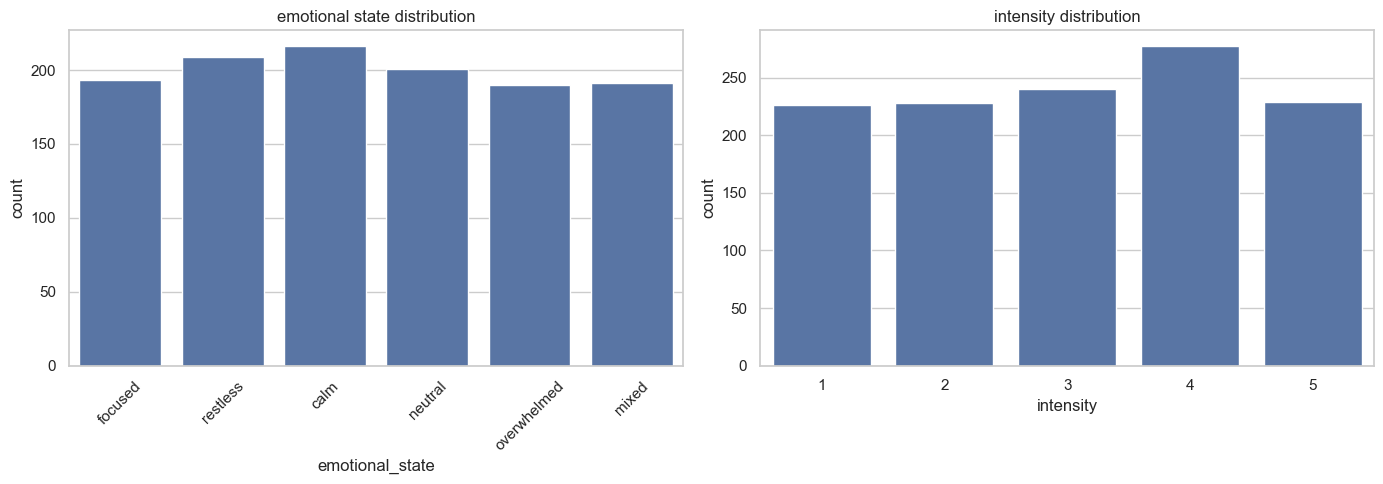

In [22]:
# 2. variable distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ploting emotional state
sns.countplot(data=df, x='emotional_state', ax=ax[0])
ax[0].set_title('emotional state distribution')
ax[0].tick_params(axis='x', rotation=45)

# intensity
sns.countplot(data=df, x='intensity', ax=ax[1])
ax[1].set_title('intensity distribution')
plt.tight_layout()
plt.show()

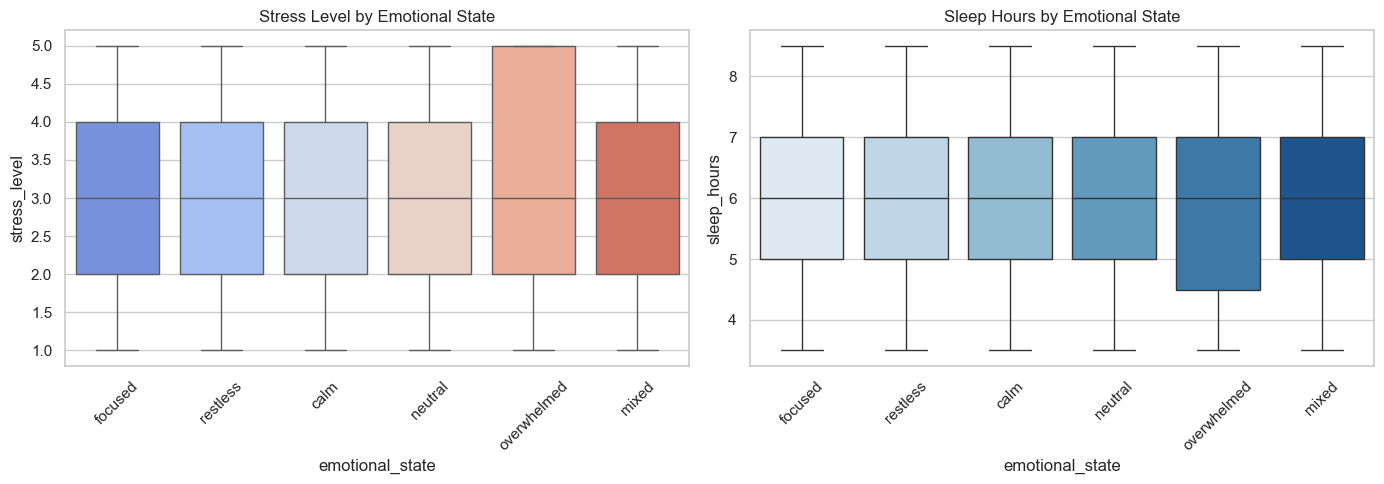

In [23]:
# 3. contextual metadata analysis
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# stress vs state
sns.boxplot(data=df, x='emotional_state', y='stress_level', palette='coolwarm', ax=ax[0])
ax[0].set_title('Stress Level by Emotional State')
ax[0].tick_params(axis='x', rotation=45)

# sleep vs state
sns.boxplot(data=df, x='emotional_state', y='sleep_hours', palette='Blues', ax=ax[1])
ax[1].set_title('Sleep Hours by Emotional State')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4. Handling the Missing Data
Real-world data is messy and we have a few gaps here. 
* **`sleep_hours`**: this is just a standard numeric column, filling in the blanks with the median makes the most sense. It is safe and will not skew the overall distribution.
* **`face_emotion_hint`**: We are missing about 10% of the data here. Dropping those rows would lose a ton of valuable journal entries. Instead we can just fillthe NaNs with the string `"missing"`.I think that the *lack* of a camera signal might actually be a useful feature. For example, if someone is doing a session late at night in bed, their camera might be off or unable to read their face.

In [24]:
# applying our strategy
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())
df['previous_day_mood'] = df['previous_day_mood'].fillna('missing')
df['face_emotion_hint'] = df['face_emotion_hint'].fillna('missing')

print("Missing values after cleaning:")
print(df.isnull().sum().max() == 0)

Missing values after cleaning:
True


### 5. Prototyping the ML Pipeline

In [25]:
text_feature = 'journal_text'
cat_features = ['ambience_type', 'time_of_day', 'previous_day_mood', 'face_emotion_hint']
num_features = ['duration_min', 'sleep_hours', 'energy_level', 'stress_level']

X = df[[text_feature] + cat_features + num_features]
y = df['emotional_state']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# building transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=500, stop_words='english'), text_feature),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ])

In [27]:
# building and training the model
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=500,
                                                                  stop_words='english'),
                                                  'journal_text'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ambience_type',
                                                   'time_of_day',
                                                   'previous_day_mood',
                                                   'face_emotion_hint']),
                                                 ('num', StandardScaler(),
                                                  ['duration_min',
                                                   'sleep_hours',
                                                   'energy_level',
                                                   'stress_level'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [29]:
# evaluating out model
y_pred = rf_model.predict(X_val)
print("Validation Classification Report --------")
print(classification_report(y_val, y_pred))

Validation Classification Report --------
              precision    recall  f1-score   support

        calm       0.62      0.55      0.58        51
     focused       0.69      0.71      0.70        41
       mixed       0.68      0.58      0.63        36
     neutral       0.72      0.50      0.59        46
 overwhelmed       0.69      0.73      0.71        37
    restless       0.45      0.79      0.57        29

    accuracy                           0.63       240
   macro avg       0.64      0.64      0.63       240
weighted avg       0.65      0.63      0.63       240



### 6. Conclusion & Next Steps
The hybrid pipeline successfully processes both text and metadata, yielding a solid baseline accuracy. 
* We also verified that Random Forest natively outputs `.predict_proba()`, which we will use to calculate our **Uncertainty Flag** (Confidence < 0.45).
* We will now wrap this logic, along with our deterministic Decision Engine, into the final `pipeline.py` script for end-to-end execution.